In [65]:
from core.exchange import Exchange
from core.columns import SYMBOL, DATE, TRADE_TIME
from core.time_utils import Bounds
from core.currency_pair import CurrencyPair
from datetime import date, timedelta, datetime

import matplotlib.pyplot as plt
import polars as pl
import pandas as pd

In [3]:
bounds: Bounds = Bounds.for_day(date(2021, 9, 5))
currency_pair: CurrencyPair = CurrencyPair.from_string("VIB-BTC")

hive: pl.LazyFrame = pl.scan_parquet(
    Exchange.BINANCE_SPOT.get_hive_location(), hive_partitioning=True
)

In [34]:
data = (
    hive.filter(
        (pl.col(SYMBOL) == currency_pair.name) &
        (pl.col(DATE).is_between(bounds.day0, bounds.day1)) &
        (pl.col(TRADE_TIME).is_between(bounds.start_inclusive, bounds.end_exclusive))
    )
    .collect()
    .sort(by=TRADE_TIME)
    .to_pandas()
    .set_index(TRADE_TIME)
)

In [50]:
candles = (
    data
    .resample("1s")
    .agg(
        Open=("price", "first"),
        Low=("price", "min"),
        High=("price", "max"),
        Close=("price", "last"),
        Volume=("quantity", "sum"),
    )
)

candles.head(2)

,Open,Low,High,Close,Volume
trade_time,,,,,
2021-09-05 00:01:12,0.000001,0.000001,0.000001,0.000001,19288.0
2021-09-05 00:01:13,NaN,NaN,NaN,NaN,0.0


In [54]:
start: datetime = datetime(2021, 9, 5, 16, 59)
end: datetime = datetime(2021, 9, 5, 17, 1)

data_plot = candles[(candles.index >= start) & (candles.index < end)]

In [52]:
import mplfinance as mpf

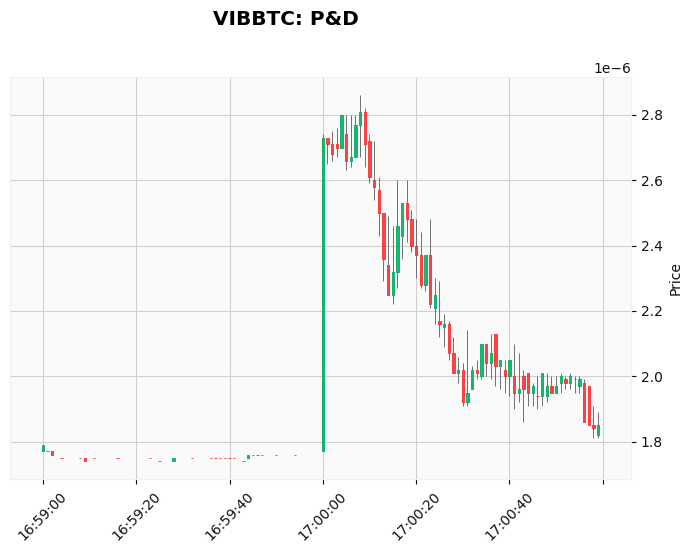

In [87]:
fig, ax = mpf.plot(
    data_plot,
    type='candle',     # 'candle' for candlesticks, 'ohlc' for OHLC bars
    style='yahoo',     # built-in style; others: 'classic', 'charles', 'checkers', ...
    title='VIBBTC: P&D',
    ylabel='Price',
    datetime_format='%H:%M:%S',
    figratio=(6, 4),
    returnfig=True
)

fig.savefig('images/pump_and_dump_example.png', dpi=300, bbox_inches='tight')

In [78]:
fig